# Using sklearn to cross-validate bayesian network classifier

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F54-Classifier_CrossValidation.ipynb)

## Overview

`BNClassifier` from `pyagrum.skbn` is a Bayesian Network-based classifier compatible with the **scikit-learn API**. This means you can use it with all standard sklearn tools such as `train_test_split`, `cross_validate`, `accuracy_score`, `confusion_matrix`, and more.

This notebook demonstrates four typical use cases on the **Iris dataset** (3 classes, 4 continuous features):

1. **`fit(X, y)`** — Standard sklearn training from a feature matrix and a label vector
2. **`fitFromData(df, targetName)`** — Training directly from a pandas DataFrame or a CSV file
3. **`fromTrainedModel(bn, targetAttribute)`** — Wrapping an existing pyAgrum Bayesian network into a sklearn-compatible classifier
4. **Cross-validation** — Using sklearn's `cross_validate` to get a robust performance estimate

In [1]:
from pyagrum.skbn import createBNClassifier

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
  accuracy_score,
  confusion_matrix,
  classification_report,
  ConfusionMatrixDisplay,
)

import pandas as pd
import matplotlib.pyplot as plt

## 1. Loading the Iris Dataset

The [Iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset) is one of the most well-known classification benchmarks.
It contains **150 samples** described by 4 continuous measurements:
- sepal length and width (cm)
- petal length and width (cm)

The target variable has **3 classes** (*setosa*, *versicolor*, *virginica*).

Since the features are continuous, `BNClassifier` will automatically **discretize** them into bins before learning the structure of the Bayesian network.

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # shape (150, 4) — continuous features
y = iris.target  # 0: setosa, 1: versicolor, 2: virginica

print(f"Samples  : {X.shape[0]}")
print(f"Features : {X.shape[1]}  →  {iris.feature_names}")
print(f"Classes  : {len(iris.target_names)}  →  {iris.target_names.tolist()}")

Samples  : 150
Features : 4  →  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes  : 3  →  ['setosa', 'versicolor', 'virginica']


In [3]:
model = createBNClassifier(
  learningMethod="MIIC",
  prior="Smoothing",
  priorWeight=1,
  discretizationNbBins=3,
  discretizationStrategy="kmeans",
  discretizationThreshold=10,
)

## 2. Training and Evaluating the Classifier

We define a `BNClassifier` using the **MIIC** structure learning algorithm and **k-means** discretization into 3 bins. A `Smoothing` prior is added to avoid zero probabilities in the conditional probability tables.

The dataset is split into a **training set (80%)** and a **test set (20%)**. The classifier is then trained with `fit(X_train, y_train)` — the standard sklearn interface — and evaluated using `accuracy_score`, `classification_report`, and a **confusion matrix**.

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



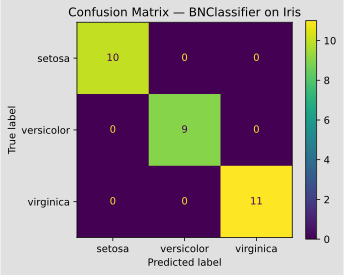

In [4]:
# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the classifier
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Overall accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

# Per-class precision, recall and F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names, ax=ax)
ax.set_title("Confusion Matrix — BNClassifier on Iris")
plt.tight_layout()
plt.show()

## 3. Loading Data with `fitFromTabular`

The `fitFromTabular(data, targetName)` method offers a more convenient interface when data is already in tabular form. Instead of separating features and labels manually, you pass either:
- a **pandas DataFrame** with a named column for the target, or
- a **CSV file path** along with the name of the target column.

This avoids the manual `X = df.drop(...)` / `y = df[...]` split required by the standard sklearn `fit(X, y)`.

In [5]:
# Build a DataFrame from the training set only (features + target column)
df_train = pd.DataFrame(X_train, columns=iris.feature_names)
df_train["species"] = y_train

# Train using fitFromTabular — target column is identified by name
model2 = createBNClassifier(
  learningMethod="MIIC",
  prior="Smoothing",
  priorWeight=1,
  discretizationNbBins=3,
  discretizationStrategy="kmeans",
  discretizationThreshold=10,
)
model2.fitFromTabular(df_train, targetName="species")

# Evaluate on the test set (features only, passed as a DataFrame)
X_test_df = pd.DataFrame(X_test, columns=iris.feature_names)
y_pred2 = model2.predict(X_test_df)
print(f"Accuracy with fitFromTabular: {accuracy_score(y_test, y_pred2):.4f}")

Accuracy with fitFromTabular: 1.0000


## 4. Building a Classifier from a Pre-trained Bayesian Network

If you already have a **trained Bayesian network** — learned externally or provided by a domain expert — you can wrap it into a `BNClassifier` using `fromTrainedModel`.

The resulting object is fully sklearn-compatible: you can call `predict`, `predict_proba`, and use it in pipelines or cross-validation.

Here we reuse the Bayesian network learned in section 2 to create a new classifier without re-training.

In [6]:
# Retrieve the Bayesian network learned in section 2
bn = model.bn_
target = model.target_  # "y" — the name assigned to the target variable during fit

# Wrap the pre-trained network into a new BNClassifier
# dtype=int ensures predictions are returned as integers, matching the original target type
model3 = createBNClassifier()
model3.fromTrainedModel(bn, targetAttribute=target, dtype=int)

# Predict on the same test set
y_pred3 = model3.predict(X_test)
print(f"Accuracy with fromTrainedModel: {accuracy_score(y_test, y_pred3):.4f}")

Accuracy with fromTrainedModel: 0.7000


## 5. Cross-Validation

One of the main advantages of the sklearn-compatible API is the ability to use `cross_validate` directly. This performs **k-fold cross-validation** and returns the score for each fold, giving a more robust performance estimate than a single train/test split.

We run the cross-validation with `cv=30` and `cv=50` folds on the full Iris dataset.

In [7]:
# 30-fold cross-validation
cv_30 = cross_validate(model, X, y, cv=30)
print(f"Fold scores   (cv=30) : {cv_30['test_score']}")
print(f"Mean accuracy (cv=30) : {cv_30['test_score'].mean():.4f}")

Fold scores   (cv=30) : [1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  0.8 1.  1.  1.  0.8 1.  1.  0.8
 1.  1.  1.  0.8 1.  1.  1.  1.  1.  1.  1.  1. ]
Mean accuracy (cv=30) : 0.9733


In [8]:
# 50-fold cross-validation
cv_50 = cross_validate(model, X, y, cv=50)
print(f"Fold scores   (cv=50) : {cv_50['test_score']}")
print(f"Mean accuracy (cv=50) : {cv_50['test_score'].mean():.4f}")

Fold scores   (cv=50) : [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.66666667 1.         1.         1.
 1.         1.         1.         0.66666667 1.         1.
 1.         1.         1.         0.66666667 1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]
Mean accuracy (cv=50) : 0.9800
